# Accessing Data

In [1]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

In [3]:
info.head()

,energy_asset,Name,Area,Dwellings,Persons,Residential,Commercial,Industrial,Primary Production,Education,Hospital/Medical,Transport,Parkland,Water,Other
BLAKE,AG_BLAKEHURST,Blakehurst,7,10081,28521,0.850,0.005,0.021,0.0,0.022,0.001,0.000,0.102,0.0,0.0
PUNCH,AG_PUNCHBOWL,Punchbowl,9,17514,50395,0.826,0.048,0.038,0.0,0.025,0.002,0.001,0.061,0.0,0.0
MEADO,AG_MEADOWBANK,Meadowbank,15,22420,56948,0.825,0.023,0.015,0.0,0.036,0.014,0.006,0.082,0.0,0.0
MOSMA,AG_MOSMAN,Mosman,11,25967,52831,0.817,0.046,0.001,0.0,0.013,0.001,0.000,0.123,0.0,0.0
RIVER,AG_RIVERWOOD,Riverwood,10,12528,34547,0.813,0.018,0.042,0.0,0.035,0.002,0.001,0.089,0.0,0.0


# Adding lat and lon into the info variable

In [7]:
from geopy.geocoders import Nominatim
import pandas as pd
import time

# Initialize geocoder
geolocator = Nominatim(user_agent="sydney_demand_mapper")

def get_coords(place):
    """Return (lat, lon) for a suburb name, or (None, None) if not found."""
    try:
        loc = geolocator.geocode(f"{place}, New South Wales, Australia")
        if loc:
            return loc.latitude, loc.longitude
    except Exception as e:
        print(f"Geocoding failed for {place}: {e}")
    return None, None

# Apply geocoding to the 'Name' column
latitudes, longitudes = [], []
for suburb in info['Name']:
    lat, lon = get_coords(suburb)
    latitudes.append(lat)
    longitudes.append(lon)
    time.sleep(1)  # polite pause to avoid hitting API limits

info['latitude'] = latitudes
info['longitude'] = longitudes

In [ ]:
info.head(20)

In [ ]:
info.loc[:, ['Name', 'latitude', 'longitude']]

In [ ]:
# Saving Name, lat and lon information as comma-separated text file
info[['Name', 'latitude', 'longitude']].to_csv('name_lat_lon.txt', index=False)


## Trouble shooting Dee Why West

In [8]:
missing = info[info["latitude"].isna() | info["longitude"].isna()]
missing["Name"].unique()
#Dee Why West doesn't exist as a suburb polygon, so will need to change the name to Dee Why

array(['Dee Why West'], dtype=object)

In [9]:
dee_why_west_lat = -33.73441
dee_why_west_lon = 151.28278
#Found the lat/lon information online

In [10]:
info.loc[info["Name"] == "Dee Why West", "latitude"] = dee_why_west_lat
info.loc[info["Name"] == "Dee Why West", "longitude"] = dee_why_west_lon
#inputting lat and lon from online into info

# Mapping

## Mapping BLAKE, CHATS, LIDC and GATES for relative ranks

In [ ]:
subset = info[info["Name"].isin(["Blakehurst", "Chatswood", "Lidcombe", "Gateshead"])]

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Filter the four substations
subset = info[info["energy_asset"].str.contains("BLAKE|CHATS|LIDC|GATES")].copy()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    subset,
    geometry=gpd.points_from_xy(subset.longitude, subset.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:3857")  # Web Mercator for basemap

# Plot
fig, ax = plt.subplots(figsize=(7, 9))
gdf.plot(ax=ax, color="red", markersize=80)

# Add labels using the Name column
for _, row in gdf.iterrows():
    ax.text(
        row.geometry.x + 200, 
        row.geometry.y + 200,
        row["Name"], 
        fontsize=10
    )

# Add basemap (stable provider)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

plt.title("Locations of Blakehurst, Chatswood, Lidcombe, Gateshead")
plt.tight_layout()

import pyproj
import numpy as np
from matplotlib.ticker import FixedLocator

# Transformer from Web Mercator → WGS84 lat/lon
to_lonlat = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

# Get current tick positions (in Web Mercator)
xticks_3857 = ax.get_xticks()
yticks_3857 = ax.get_yticks()

# Convert to lon/lat
lon_ticks, lat_ticks = to_lonlat.transform(xticks_3857, yticks_3857)

# Set tick positions explicitly
ax.xaxis.set_major_locator(FixedLocator(xticks_3857))
ax.yaxis.set_major_locator(FixedLocator(yticks_3857))

# Set tick labels
ax.set_xticklabels([f"{lon:.3f}" for lon in lon_ticks])
ax.set_yticklabels([f"{lat:.3f}" for lat in lat_ticks])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Axis labels
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


plt.show()


## Mapping all

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# 1. Convert ALL substations to a GeoDataFrame in EPSG:4326
gdf = gpd.GeoDataFrame(
    info,
    geometry=gpd.points_from_xy(info.longitude, info.latitude),
    crs="EPSG:4326"
)

# 2. Plot directly in geographic coordinates
fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color="red", markersize=20, alpha=0.8)

# Optional: label each point
for _, row in gdf.iterrows():
    ax.text(
        row.geometry.x + 0.01,
        row.geometry.y + 0.01,
        row["Name"],
        fontsize=6
    )

# 3. Add basemap — Contextily will reproject automatically
ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.CartoDB.Positron)

# 4. Titles and labels
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.title("All Substation Locations")
plt.tight_layout()
plt.show()


## Creating a list of substations closest to furthest from coastline

In [ ]:
#downloading natural earth coastline at 10m resolution

import requests, zipfile, io, geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip"
r = requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("natural_earth_coastline")

coast = gpd.read_file("/home/565/pv3484/aus_substation_electricity/data/natural_earth_coastline/ne_10m_coastline.shp")


In [ ]:
#Australia segment of global coastline

# Rough bounding box for Australia
minx, miny = 110, -45
maxx, maxy = 155, -10

coast_aus = coast.cx[minx:maxx, miny:maxy]


In [ ]:
#coverting datasets for distance calculations

info_gdf = gpd.GeoDataFrame(
    info,
    geometry=gpd.points_from_xy(info.longitude, info.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

coast_3857 = coast_aus.to_crs("EPSG:3857")


In [ ]:
#computing distance in meters
info_gdf["dist_to_coast_m"] = info_gdf.geometry.apply(
    lambda p: coast_3857.distance(p).min()
)

#convert to km
info_gdf["dist_to_coast_km"] = info_gdf["dist_to_coast_m"] / 1000


In [ ]:
#sorting closest to furthest and residential fraction
ranked = info_gdf.sort_values("dist_to_coast_km")[
    ["energy_asset", "Name", "Residential", "dist_to_coast_km"]
]


In [ ]:
print(ranked.to_string(index=False))


In [ ]:
subset = info_gdf[
    info_gdf["Name"].isin(["Blakehurst", "Chatswood", "Gateshead", "Lidcombe"])
][["Name", "Residential", "dist_to_coast_km"]]

print(subset.to_string(index=False))


# Weather station to Substation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KDTree
import geopandas as gpd
from shapely.geometry import Point

# -----------------------------
# 1. Load your datasets
# -----------------------------

weather_path = "/home/565/pv3484/aus_substation_electricity/data/raw_data/All_weatherstations_information.xlsx"
substation_path = "/home/565/pv3484/aus_substation_electricity/pia_notebooks/NSW_data/relative_ranking/name_lat_lon.txt"

# Load substations (comma-separated)
subs = pd.read_csv(substation_path, sep=",", engine="python")
subs = subs.rename(columns=str.lower)

subs = subs.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})

weather = pd.read_excel(weather_path)
weather = weather.rename(columns=str.lower)

# FIX: rename to the names your code expects
weather = weather.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})

gdf_weather = gpd.GeoDataFrame(
    weather,
    geometry=gpd.points_from_xy(weather.lon, weather.lat),
    crs="EPSG:4326"
)

# -----------------------------
# 2. Convert to GeoDataFrames
# -----------------------------

gdf_weather = gpd.GeoDataFrame(
    weather,
    geometry=gpd.points_from_xy(weather.lon, weather.lat),
    crs="EPSG:4326"
)

gdf_subs = gpd.GeoDataFrame(
    subs,
    geometry=gpd.points_from_xy(subs.lon, subs.lat),
    crs="EPSG:4326"
)

# Convert to metric CRS for distance calculations (Australia Albers)
gdf_weather = gdf_weather.to_crs("EPSG:3577")
gdf_subs = gdf_subs.to_crs("EPSG:3577")

# -----------------------------
# 3. Build KD-tree on weather stations
# -----------------------------

weather_coords = np.vstack([gdf_weather.geometry.x, gdf_weather.geometry.y]).T
tree = KDTree(weather_coords)

# -----------------------------
# 4. Query nearest weather station for each substation
# -----------------------------

sub_coords = np.vstack([gdf_subs.geometry.x, gdf_subs.geometry.y]).T
distances, indices = tree.query(sub_coords, k=1)

gdf_subs["nearest_station_id"] = gdf_weather.iloc[indices.flatten()].station_number.values
gdf_subs["distance_km"] = distances.flatten() / 1000

# -----------------------------
# 5. Save mapping table
# -----------------------------

output_path = "/home/565/pv3484/aus_substation_electricity/pia_notebooks/NSW_data/relative_ranking/substation_to_weather_mapping.csv"

gdf_subs.drop(columns="geometry").to_csv(output_path, index=False)


print("Saved:", output_path)


In [ ]:
print(subs.columns)


In [ ]:
import pandas as pd

mapping_path = "/home/565/pv3484/aus_substation_electricity/pia_notebooks/NSW_data/relative_ranking/substation_to_weather_mapping.csv"

df = pd.read_csv(mapping_path)

unique_ids = df["nearest_station_id"].drop_duplicates()

print(unique_ids.to_list())


In [ ]:
unique_ids.to_csv(
    "/home/565/pv3484/aus_substation_electricity/pia_notebooks/NSW_data/relative_ranking/unique_weather_station_ids.txt",
    index=False,
    header=False
)


# Mapping all substations with residential fractions over 0.75

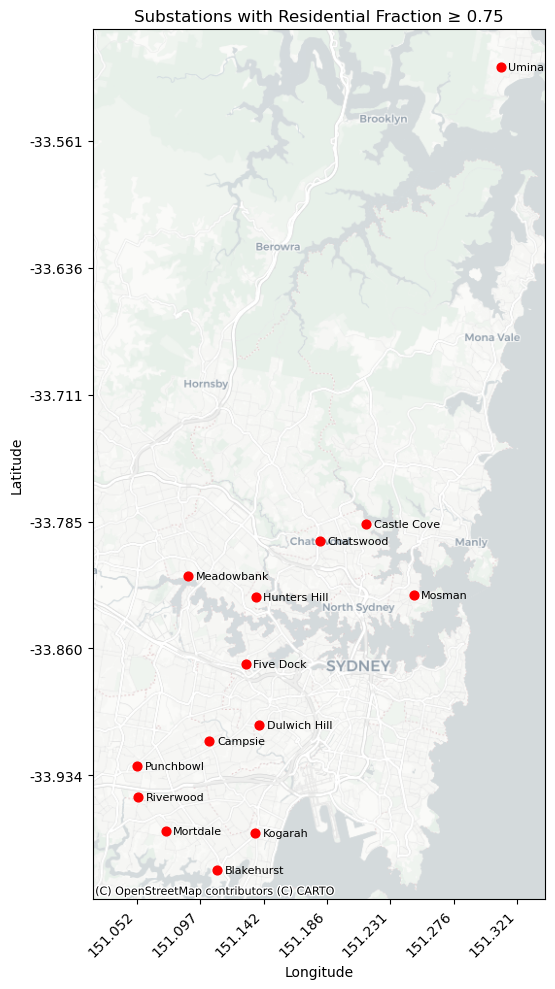

In [53]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import pyproj
import numpy as np
from matplotlib.ticker import FixedLocator

# -----------------------------
# Filter data
# -----------------------------
high_res = info[info["Residential"] >= 0.75].copy()

# -----------------------------
# Convert to GeoDataFrame
# -----------------------------
gdf = gpd.GeoDataFrame(
    high_res,
    geometry=gpd.points_from_xy(high_res.longitude, high_res.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

# -----------------------------
# Plot (auto-zoom)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(ax=ax, color="red", markersize=40)

# -----------------------------
# Labels (600 m to the right)
# -----------------------------
x_offset = 600  # metres

for _, row in gdf.iterrows():
    ax.text(
        row.geometry.x + x_offset,
        row.geometry.y,
        row["Name"],
        fontsize=8,
        ha="left",
        va="center"
    )

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# --- Compute true bounds of the filtered substations ---
xmin, ymin, xmax, ymax = gdf.total_bounds

# --- Apply a small zoom-out buffer (in metres, EPSG:3857) ---
x_buffer = 3500        # slight horizontal zoom-out
y_buffer_top = 3000    # a bit more room above Umina
y_buffer_bottom = 800  # minimal room below

extra_bottom = 1500

ax.set_xlim(xmin - x_buffer, xmax + x_buffer)
ax.set_ylim(ymin - (y_buffer_bottom + extra_bottom), ymax + y_buffer_top)

# -----------------------------
# Tick conversion (AFTER padding)
# -----------------------------
xticks_3857 = ax.get_xticks()
yticks_3857 = ax.get_yticks()

to_lonlat = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

lon_ticks, _ = to_lonlat.transform(xticks_3857, np.zeros_like(xticks_3857))
_, lat_ticks = to_lonlat.transform(np.zeros_like(yticks_3857), yticks_3857)

ax.xaxis.set_major_locator(FixedLocator(xticks_3857))
ax.yaxis.set_major_locator(FixedLocator(yticks_3857))

ax.set_xticklabels([f"{lon:.3f}" for lon in lon_ticks])
ax.set_yticklabels([f"{lat:.3f}" for lat in lat_ticks])

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")


ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.title("Substations with Residential Fraction ≥ 0.75")

plt.tight_layout()
plt.show()
